# 03 — Feature Engineering

**Objectives:**
- Engineer new features from existing ones
- Analyse multicollinearity (VIF)
- Measure feature importance (tree-based)
- Select final feature set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
RANDOM_STATE  = 42

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (25343, 17) | X_test: (6336, 17)


## 1. Feature Engineering
New features that capture domain-relevant relationships not directly 
represented in the raw columns.

In [2]:
def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    """Create domain-driven features for credit risk prediction.

    Args:
        X: Preprocessed feature DataFrame.

    Returns:
        DataFrame with additional engineered columns.
    """
    X = X.copy()

    # Debt burden: what fraction of income goes to this loan
    # Higher -> higher repayment stress
    X['debt_to_income'] = X['loan_amnt'] / (X['person_income'] + 1)

    # Income per year of employment - proxy for earning trajectory
    X['income_per_emp_year'] = X['person_income'] / (X['person_emp_length'] + 1)

    # Rate-to-grade ratio: captures if rate is high relative to grade
    # (loan_grade already encoded 1-7; higher grade number = riskier)
    X['rate_per_grade'] = X['loan_int_rate'] / (X['loan_grade'] + 1)

    # Credit utilisation proxy: loan amount relative to credit history length
    X['loan_per_cred_year'] = X['loan_amnt'] / (X['cb_person_cred_hist_length'] + 1)

    # Age-to-employment ratio: how much of working life is employed
    X['emp_age_ratio'] = X['person_emp_length'] / (X['person_age'] + 1)

    return X

X_train = engineer_features(X_train)
X_test  = engineer_features(X_test)

new_features = ['debt_to_income', 'income_per_emp_year', 'rate_per_grade',
                'loan_per_cred_year', 'emp_age_ratio']
print('New features added:')
X_train[new_features].describe().round(3)

New features added:


,debt_to_income,income_per_emp_year,rate_per_grade,loan_per_cred_year,emp_age_ratio
count,25343.000,25343.000,25343.000,25343.000,25343.000
mean,-0.748,-0.127,-0.109,-0.179,-0.338
std,28.813,5.514,0.357,6.587,3.355
min,-3545.353,-197.368,-0.878,-22.200,-15.211
25%,-1.095,-0.630,-0.491,-1.235,-0.951
50%,-0.224,-0.114,-0.005,-0.201,-0.159
75%,0.511,0.406,0.190,0.663,1.187
max,542.899,352.665,0.502,61.542,14.182


## 2. Multicollinearity — VIF Analysis
Variance Inflation Factor (VIF) measures how much a feature's variance is inflated 
by correlation with others. VIF > 10 indicates severe multicollinearity.
We flagged loan_int_rate <-> loan_grade correlation in EDA - let's quantify it.

                   Feature       VIF
             loan_int_rate 18.682052
            rate_per_grade 15.349765
                person_age  4.430566
cb_person_cred_hist_length  4.382257
                loan_grade  3.107837
                 loan_amnt  2.977308
       loan_percent_income  2.443217
             person_income  1.902233
        loan_per_cred_year  1.513597
         person_emp_length  1.282371
             emp_age_ratio  1.233698
       income_per_emp_year  1.107861
            debt_to_income  1.004881


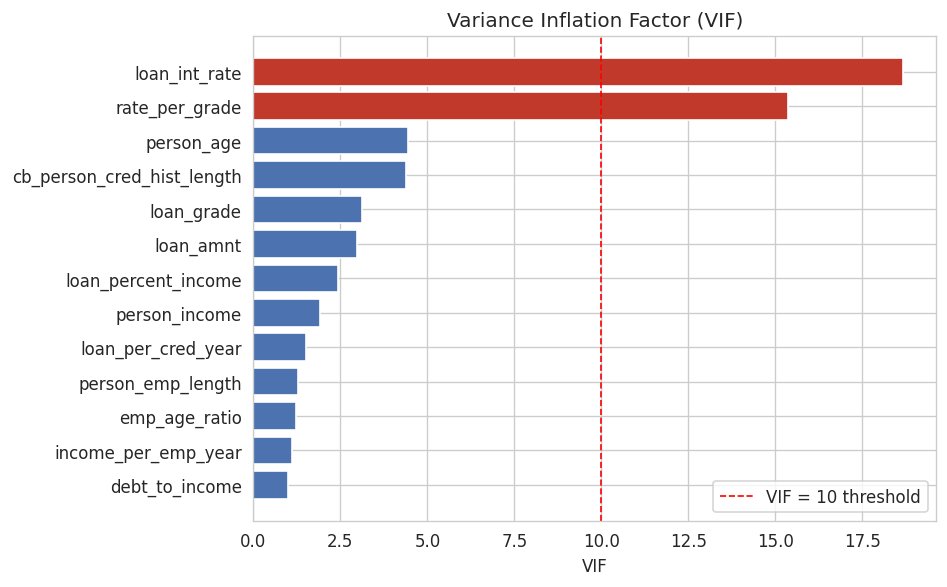

In [ ]:
# VIF requires no nulls and numeric-only data
# Use only original numerical cols (not dummies - VIF not meaningful for binary)
VIF_COLS = [
    'person_age', 'person_income', 'person_emp_length', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
    'loan_grade', 'debt_to_income', 'income_per_emp_year',
    'rate_per_grade', 'loan_per_cred_year', 'emp_age_ratio'
]

vif_data = pd.DataFrame({
    'Feature': VIF_COLS,
    'VIF': [
        variance_inflation_factor(X_train[VIF_COLS].values, i)
        for i in range(len(VIF_COLS))
    ]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_data.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#c0392b' if v > 10 else '#4C72B0' for v in vif_data['VIF']]
ax.barh(vif_data['Feature'][::-1], vif_data['VIF'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(10, color='red', linestyle='--', linewidth=1, label='VIF = 10 threshold')
ax.set_title('Variance Inflation Factor (VIF)')
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()

**Findings:**
- If loan_int_rate or loan_grade shows VIF > 10, consider dropping one.
- loan_grade is ordinal and more directly interpretable - prefer keeping it over 
  loan_int_rate if forced to choose.
- Engineered features derived from correlated columns may also show elevated VIF - 
  monitor and drop if > 10.

## 3. Feature Importance - Random Forest
We use a quick Random Forest to rank features by impurity-based importance 
before final selection.

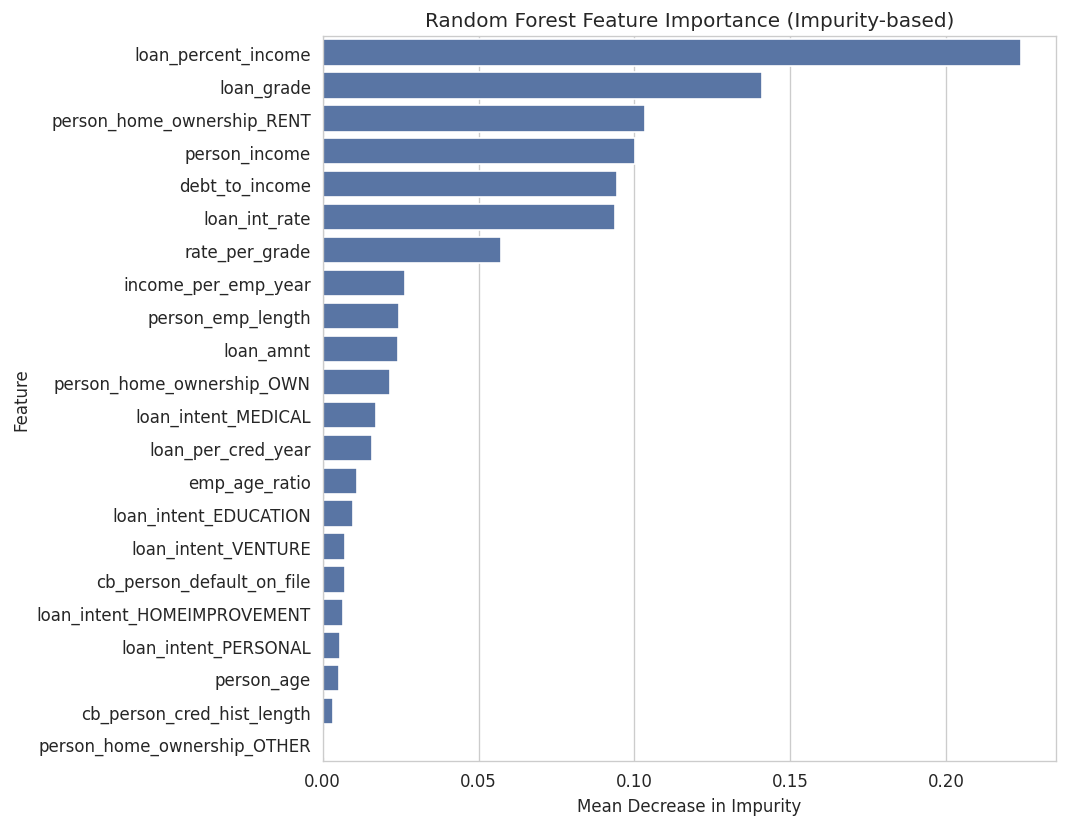

In [4]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

importance_df = (
    pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=importance_df, x='Importance', y='Feature', ax=ax,
            color='#4C72B0', edgecolor='white')
ax.set_title('Random Forest Feature Importance (Impurity-based)')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

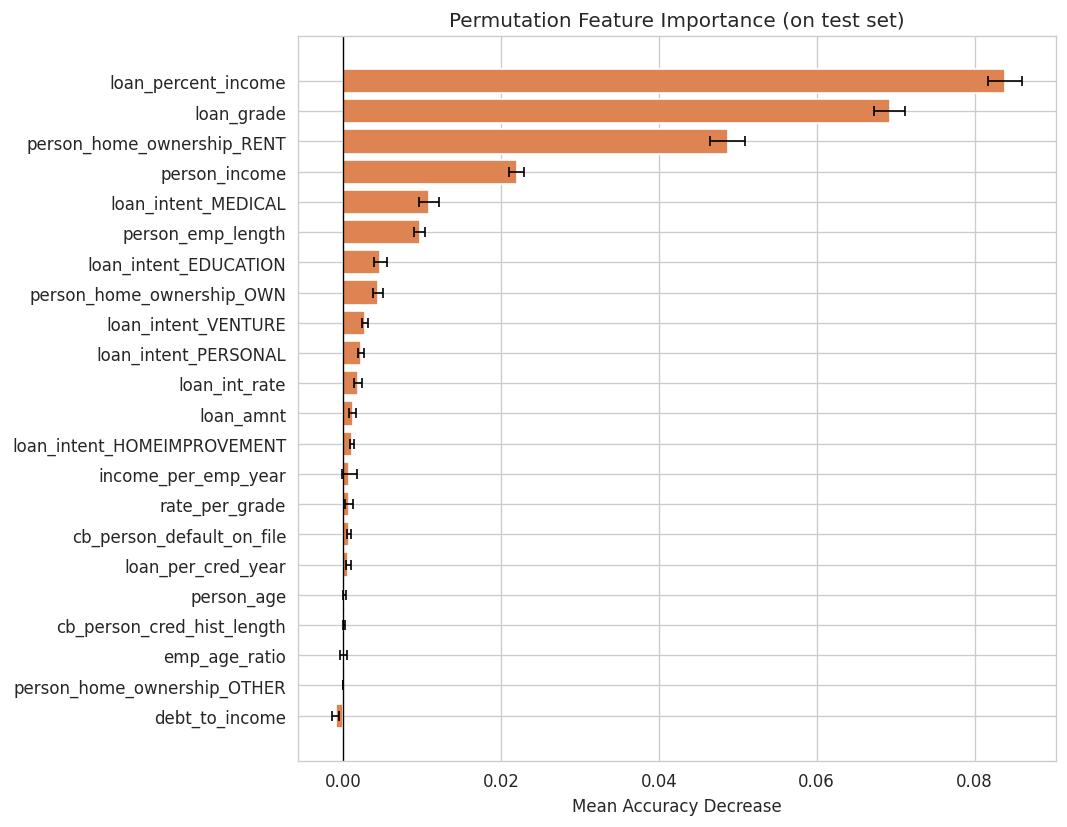

In [5]:
perm = permutation_importance(rf, X_test, y_test,
                               n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)

perm_df = (
    pd.DataFrame({'Feature': X_train.columns,
                  'Importance': perm.importances_mean,
                  'Std': perm.importances_std})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
        xerr=perm_df['Std'][::-1], color='#DD8452', edgecolor='white',
        error_kw={'elinewidth': 1, 'capsize': 3})
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Permutation Feature Importance (on test set)')
ax.set_xlabel('Mean Accuracy Decrease')
plt.tight_layout()
plt.show()

**Why permutation importance over impurity-based?**
> Impurity-based importance favours high-cardinality features and can overstate 
importance of numerical columns. Permutation importance directly measures the 
drop in model performance when a feature's values are shuffled - more reliable 
for feature selection decisions.

## 4. Feature Selection
Drop features with near-zero permutation importance and any with VIF > 10 
that are redundant with a more interpretable feature.

In [6]:
# Drop features with permutation importance <= 0 (they hurt or don't help)
DROP_FEATURES = perm_df[perm_df['Importance'] <= 0]['Feature'].tolist()
print('Features to drop (importance ≤ 0):', DROP_FEATURES)

X_train_selected = X_train.drop(columns=DROP_FEATURES, errors='ignore')
X_test_selected  = X_test.drop(columns=DROP_FEATURES, errors='ignore')

print(f'\nFinal feature count: {X_train_selected.shape[1]}')
print('Selected features:', list(X_train_selected.columns))

Features to drop (importance ≤ 0): ['person_home_ownership_OTHER', 'debt_to_income']

Final feature count: 20
Selected features: ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'income_per_emp_year', 'rate_per_grade', 'loan_per_cred_year', 'emp_age_ratio']


In [7]:
X_train_selected.to_csv(PROCESSED_DIR / 'X_train_selected.csv', index=False)
X_test_selected.to_csv(PROCESSED_DIR  / 'X_test_selected.csv',  index=False)

print('Saved X_train_selected.csv and X_test_selected.csv')

Saved X_train_selected.csv and X_test_selected.csv


## 5. Summary

| Step | Action |
|---|---|
| **New features** | 5 domain-driven features created (debt_to_income, rate_per_grade, etc.) |
| **VIF analysis** | Identified multicollinear features; flagged for review |
| **Importance** | Ranked all features by RF impurity + permutation importance |
| **Selection** | Dropped features with permutation importance ≤ 0 |
